In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from apyori import apriori

In [2]:
basket = pd.read_csv('./Market_Basket.csv',header=None)
basket

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
basketList = (basket.to_numpy())
basketList

array([['shrimp', 'almonds', 'avocado', ..., 'frozen smoothie',
        'spinach', 'olive oil'],
       ['burgers', 'meatballs', 'eggs', ..., nan, nan, nan],
       ['chutney', nan, nan, ..., nan, nan, nan],
       ...,
       ['chicken', nan, nan, ..., nan, nan, nan],
       ['escalope', 'green tea', nan, ..., nan, nan, nan],
       ['eggs', 'frozen smoothie', 'yogurt cake', ..., nan, nan, nan]],
      dtype=object)

<Axes: xlabel='None', ylabel='count'>

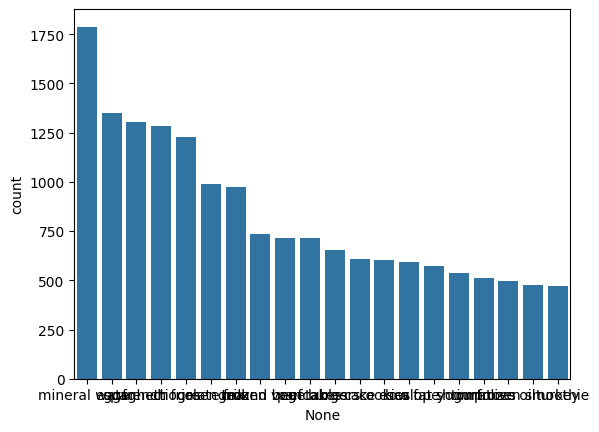

In [4]:
x2=pd.Series(basketList.flatten())
x2.dropna(inplace=True)

sns.barplot(x=x2.value_counts().head(20).index,y=x2.value_counts().head(20))

In [5]:
basketList = basketList.tolist()
for x in basketList:
    while np.nan in x:
        x.remove(np.nan)
        
basketList

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['frozen vegetables', 'spaghetti', 'green tea'],
 ['french fries'],
 ['eggs', 'pet food'],
 ['cookies'],
 ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'],
 ['spaghetti', 'champagne', 'cookies'],
 ['mineral water', 'salmon'],
 ['mineral water'],
 ['shrimp',
  'chocolate',
  'chicken',
  'honey',
  'oil',
  'cooking oil',
  'low fat yogurt'],
 ['turkey', 'eggs'],
 ['turkey',
  'fresh tuna',
  'tomatoes',
  'spagh

In [6]:
rules1 = apriori(basketList,min_support=0.009,min_confidence=0.09)
r1 = list(rules1)
r1

[RelationRecord(items=frozenset({'chocolate'}), support=0.1638448206905746, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'chocolate'}), confidence=0.1638448206905746, lift=1.0)]),
 RelationRecord(items=frozenset({'eggs'}), support=0.17970937208372217, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'eggs'}), confidence=0.17970937208372217, lift=1.0)]),
 RelationRecord(items=frozenset({'french fries'}), support=0.1709105452606319, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'french fries'}), confidence=0.1709105452606319, lift=1.0)]),
 RelationRecord(items=frozenset({'frozen vegetables'}), support=0.09532062391681109, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'frozen vegetables'}), confidence=0.09532062391681109, lift=1.0)]),
 RelationRecord(items=frozenset({'green tea'}), support=0.13211571790427942, ordered_statistics=[OrderedStatistic(it

In [7]:
rules2 = apriori(basketList,min_support=0.008,min_confidence=0.02)
r2 = list(rules2)

In [8]:
frequent_items = []
added_items = []
supports = []
confidences = []
lifts = []

In [9]:
for r in r1:
    if(len(r.ordered_statistics[0].items_base)==0):
        continue
    frequent_items.append(r.ordered_statistics[0].items_base)
    added_items.append(r.ordered_statistics[0].items_add)
    supports.append(r.support)
    confidences.append(r.ordered_statistics[0].confidence)
    lifts.append(r.ordered_statistics[0].lift)


In [10]:
rules1_df = pd.DataFrame()
rules1_df['Base items']=frequent_items
rules1_df['Added items']=added_items
rules1_df['support']=supports
rules1_df['Confidence']=confidences
rules1_df['Lift']=lifts
rules1_df

,Base items,Added items,support,Confidence,Lift
0,(avocado),(mineral water),0.011598,0.348000,1.459926
1,(brownies),(mineral water),0.009599,0.284585,1.193888
2,(burgers),(cake),0.011465,0.131498,1.622319
3,(burgers),(chocolate),0.017064,0.195719,1.194537
4,(burgers),(eggs),0.028796,0.330275,1.837830
...,...,...,...,...,...
220,(ground beef),"(mineral water, spaghetti)",0.017064,0.173677,2.907928
221,(milk),"(mineral water, spaghetti)",0.015731,0.121399,2.032623
222,(olive oil),"(mineral water, spaghetti)",0.010265,0.155870,2.609786
223,(pancakes),"(mineral water, spaghetti)",0.011465,0.120617,2.019529


In [11]:
rules1_df.sort_values(by="Lift",ascending=False)

,Base items,Added items,support,Confidence,Lift
138,(ground beef),(herb & pepper),0.015998,0.162822,3.291994
220,(ground beef),"(mineral water, spaghetti)",0.017064,0.173677,2.907928
199,(burgers),"(french fries, eggs)",0.009065,0.103976,2.856852
219,(ground beef),"(milk, spaghetti)",0.009732,0.099050,2.793141
222,(olive oil),"(mineral water, spaghetti)",0.010265,0.155870,2.609786
...,...,...,...,...,...
99,(shrimp),(french fries),0.009999,0.139925,0.818705
97,(olive oil),(french fries),0.009199,0.139676,0.817247
35,(cookies),(chocolate),0.010399,0.129353,0.789486
67,(escalope),(eggs),0.011065,0.139496,0.776230


In [12]:
frequent_items.clear()
supports.clear()
confidences.clear()
lifts.clear()
added_items.clear()
for r in r2:
    if(len(r.ordered_statistics[0].items_base)==0):
        continue
    frequent_items.append(r.ordered_statistics[0].items_base)
    added_items.append(r.ordered_statistics[0].items_add)
    supports.append(r.support)
    confidences.append(r.ordered_statistics[0].confidence)
    lifts.append(r.ordered_statistics[0].lift)

In [13]:
rules2_df = pd.DataFrame()
rules2_df['Base Items']=frequent_items
rules2_df['Added Items']=added_items
rules2_df['support']=supports
rules2_df['Confidence']=confidences
rules2_df['Lift']=lifts
rules2_df

,Base Items,Added Items,support,Confidence,Lift
0,(avocado),(mineral water),0.011598,0.348000,1.459926
1,(brownies),(mineral water),0.009599,0.284585,1.193888
2,(burgers),(cake),0.011465,0.131498,1.622319
3,(burgers),(chocolate),0.017064,0.195719,1.194537
4,(burgers),(frozen vegetables),0.010532,0.120795,1.267250
...,...,...,...,...,...
207,(milk),"(mineral water, spaghetti)",0.015731,0.121399,2.032623
208,(mineral water),"(olive oil, spaghetti)",0.010265,0.043065,1.878079
209,(mineral water),"(pancakes, spaghetti)",0.011465,0.048098,1.908923
210,(mineral water),"(shrimp, spaghetti)",0.008532,0.035794,1.688630


In [14]:
rules2_df.sort_values(by="Lift",ascending=False)

,Base Items,Added Items,support,Confidence,Lift
123,(ground beef),(herb & pepper),0.015998,0.162822,3.291994
204,(ground beef),"(mineral water, spaghetti)",0.017064,0.173677,2.907928
174,(burgers),"(french fries, eggs)",0.009065,0.103976,2.856852
206,(milk),"(soup, mineral water)",0.008532,0.065844,2.854873
203,(ground beef),"(milk, spaghetti)",0.009732,0.099050,2.793141
...,...,...,...,...,...
88,(french fries),(shrimp),0.009999,0.058502,0.818705
87,(french fries),(olive oil),0.009199,0.053822,0.817247
37,(chocolate),(cookies),0.010399,0.063466,0.789486
61,(eggs),(escalope),0.011065,0.061573,0.776230
